In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/user_daily_features.csv")
print(df.shape)
df.head()

(330268, 7)


,user,day,logon_count,after_hours_logon_count,distinct_pc_count,usb_connect_count,is_insider_day
0,AAE0190,2010-01-04,1,0,1,0.0,0
1,AAE0190,2010-01-05,1,0,1,0.0,0
2,AAE0190,2010-01-06,1,0,1,0.0,0
3,AAE0190,2010-01-07,1,0,1,0.0,0
4,AAE0190,2010-01-08,1,0,1,0.0,0


In [2]:
insider_counts = df['is_insider_day'].value_counts()
print(insider_counts)
print(f"\nInsider day percentage: {df['is_insider_day'].mean() * 100:.3f}%")

is_insider_day
0    328906
1      1362
Name: count, dtype: int64

Insider day percentage: 0.412%


In [3]:
comparison = df.groupby('is_insider_day')[
    ['logon_count', 'after_hours_logon_count', 'distinct_pc_count', 'usb_connect_count']
].mean()
comparison.index = ['Normal Days', 'Insider Days']
comparison

,logon_count,after_hours_logon_count,distinct_pc_count,usb_connect_count
Normal Days,1.424814,0.095666,1.151825,0.607198
Insider Days,1.439794,0.187959,1.199706,2.654185


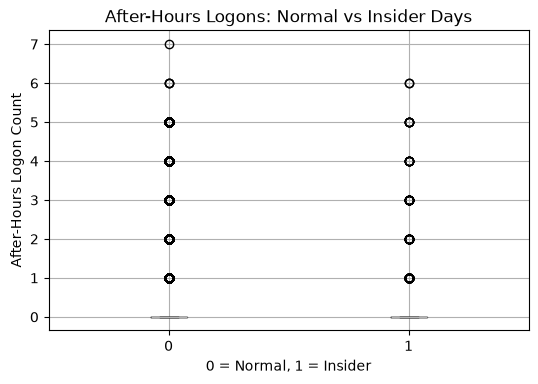

In [4]:
fig, ax = plt.subplots(figsize=(6,4))
df.boxplot(column='after_hours_logon_count', by='is_insider_day', ax=ax)
plt.title('After-Hours Logons: Normal vs Insider Days')
plt.suptitle('')
plt.xlabel('0 = Normal, 1 = Insider')
plt.ylabel('After-Hours Logon Count')
plt.savefig('../outputs/plots/after_hours_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

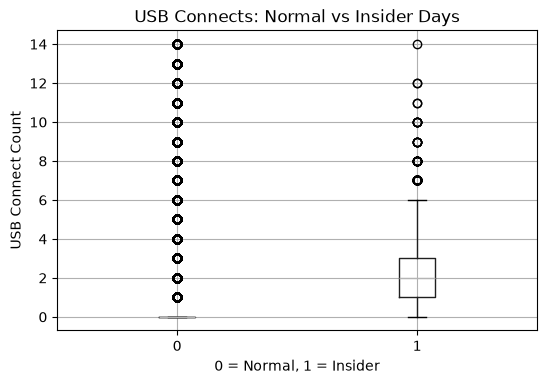

In [5]:
fig, ax = plt.subplots(figsize=(6,4))
df.boxplot(column='usb_connect_count', by='is_insider_day', ax=ax)
plt.title('USB Connects: Normal vs Insider Days')
plt.suptitle('')
plt.xlabel('0 = Normal, 1 = Insider')
plt.ylabel('USB Connect Count')
plt.savefig('../outputs/plots/usb_connects_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

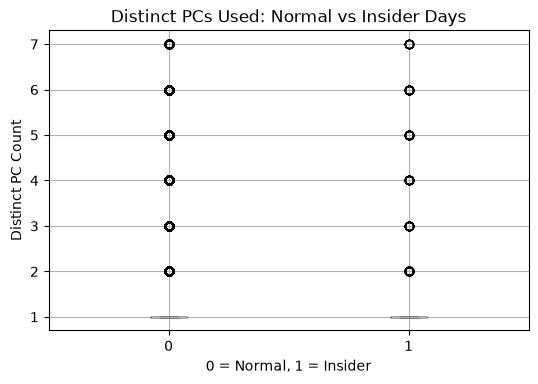

: 

In [ ]:
fig, ax = plt.subplots(figsize=(6,4))
df.boxplot(column='distinct_pc_count', by='is_insider_day', ax=ax)
plt.title('Distinct PCs Used: Normal vs Insider Days')
plt.suptitle('')
plt.xlabel('0 = Normal, 1 = Insider')
plt.ylabel('Distinct PC Count')
plt.savefig('../outputs/plots/distinct_pc_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()